<h2>Evaluación del desempeño de SVM en la clasificación de imágenes de perros y gatos - Aprendizaje Automático 2-2024</h2>

* <h5>Nombre: Xavier Muñoz Díaz</h3>
* <h5>Profesora: Violeta Chang Camacho</h3>
* <h5>Ayudante: Marcelo Guzmán</h3>

<h3>Definiciones</h3>

- MLP: Tipo de red neuronal artificial formada por varias capas de neuronas, las cuales suelen utilizar funciones de activación no lineales permitiendo a la red aprender patrones complejos en los datos (Jaiswal, 2024).
- Función de activación: Determina la salida de una neurona dada su entrada e introducen la no linealidad en la red, permitiéndole aprender patrones complejos en los datos (Jaiswal, 2024).
- Función de pérdida: Medida de lo bien que coinciden las predicciones del modelo con los verdaderos valores objetivo de los datos de entrenamiento.Además, cuantifica la diferencia entre la salida prevista del modelo y la salida real (Jaiswal, 2024).

Los optimizadores utilizados son los siguientes:
- Nadam: La idea intuitiva es acelerar más o menos el descenso de la curva de gradiente, según la pendiente de la misma, yendo más rápido en las direcciones en que la curva de la función de pérdida es más escarpada y más lento en las direcciones en que la curva presenta un perfil más suave (Gavilán, 2020).
- Adamw: Es un método de optimización estocástica que modifica la implementación típica del decaimiento del peso en Adam (Papers With Code - AdamW Explained, s. f.).
- Adam: Utiliza una media móvil exponencial de los gradientes para ajustar las tasas de aprendizaje (Gavilán, 2020).

<h3>Actividades a desarrollar</h3>

El objetivo de este laboratorio es entender y aplicar redes neuronales para reconocimiento de dígitos y letras manuscritas. Para ello, se utilizarán dos subconjuntos del dataset EMMIST: EMNIST Digits y EMNIST Letters. El primero tiene 10 clases y 280.000 imágenes, mientras que el segundo tiene 26 clases y 145.600 imágenes.

Para llevar a cabo este análisis, se realizarán dos experimentos, en los cuales se deben entrenar 3 modelos MLP que posean entre 2 y 4 capas ocultas, ocupar al menos dos funciones de activación diferentes, ocupar al menos 2 funciones de pérdida diferente y ocupar pesos inicializados al azar.

1) Entrenar 3 MLP con al menos 5 entrenamientos y evaluaciones para cada modelo utilizando el conjunto de datos EMNIST_Digits.

2) Similar al experimento anterior pero con la diferencia que se utiliza el conjunto de datos EMNIST_Letters.

 Los resultados se analizarán en términos de precisión de cada clase en cada modelo apoyados en la matriz de confusión.

<h3>Importaciones de Librerias</h3>

In [1]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import pandas as pd
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Nadam, Adam, AdamW
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import tensorflow as tf

<h3>Semilla</h3>
Se utiliza una semilla para la replicación del experimento

In [2]:
#Definir semilla
np.random.seed(0)

<h3>Función de carga de datasets de entrenamiento y prueba con su etiquetado</h3>

In [3]:
'''
Descripción: Carga los datos de las imágenes y etiquetas desde archivos comprimidos gzip.
Entrada:
    - ruta_imagenes (str): Ruta al archivo gzip que contiene las imágenes.
    - ruta_etiquetas (str): Ruta al archivo gzip que contiene las etiquetas.
Salida:
    - imagenes: Arreglo normalizado de imágenes en escala [0, 1].
    - etiquetas: Arreglo de etiquetas correspondientes a las imágenes.
'''
def cargar_datos(ruta_imagenes, ruta_etiquetas):
    with gzip.open(ruta_imagenes, 'rb') as archivo:
        archivo.read(4) # Descarta los primeros 4 bytes del archivo porque no son relevantes
        cantidad_imagenes = int.from_bytes(archivo.read(4), 'big')
        filas = int.from_bytes(archivo.read(4), 'big')
        columnas = int.from_bytes(archivo.read(4), 'big')
        tamanyo_imagen = filas * columnas
        imagenes = np.frombuffer(archivo.read(), dtype=np.uint8).reshape(cantidad_imagenes, tamanyo_imagen)

    with gzip.open(ruta_etiquetas, 'rb') as archivo:
        archivo.read(4)
        cantidad_etiquetas = int.from_bytes(archivo.read(4), 'big')
        etiquetas = np.frombuffer(archivo.read(), dtype=np.uint8)


    return imagenes/255.0, etiquetas

<h3>Función para cargar el mapping</h3>

In [4]:
'''
Descripción: Carga un mapeo de claves de un dataset a valores desde un archivo de texto
Entrada:
    - ruta_archivo (str): Ruta al archivo de texto que contiene el mapeo.
    - dataset (str): Tipo de dataset; puede ser "digits" o "letters". Por defecto es "digits".
Salida:
    - mapping (dict): Diccionario que mapea claves a valores. Para el subconjunto letters, los valores son tuplas (mayúscula, minúscula).
'''
def cargar_mapping(ruta_archivo, dataset):
    mapping = {}
    with open(ruta_archivo, 'r') as archivo:
        for linea in archivo:
            linea_aux = linea.strip().split()
            if dataset == "letters":
                clave, valor_mayusculas, valor_minusculas = map(int, linea_aux)
                mapping[clave] = (valor_mayusculas, valor_minusculas)
            else:  # Para "digits"
                clave, valor = map(int, linea_aux)
                mapping[clave] = valor
    return mapping

<h3>Función para mostrar imágenes de los datasets</h3>

In [5]:
'''
Descripción: Muestra imágenes aleatoriamente junto con sus etiquetas en una cuadrícula.
Entrada:
    - imagenes (numpy.ndarray): Arreglo de imágenes.
    - etiquetas (numpy.ndarray): Arreglo de etiquetas de las imágenes.
    - mapping (dict): Diccionario para mapear las etiquetas.
    - cantidad (int): Número de imágenes a seleccionar y mostrar.
    - titulo (str): Título de la figura generada.
Salida: No retorna ningún valor, solo muestra la figura.
'''
def mostrar_imagenes_aleatorias(imagenes, etiquetas, mapping, cantidad, titulo):
    indices = random.sample(range(imagenes.shape[0]), cantidad)
    imagenes_seleccionadas = imagenes[indices]
    etiquetas_seleccionadas = etiquetas[indices]

    filas = int(np.sqrt(cantidad))
    columnas = int(np.ceil(cantidad / filas))

    plt.figure(figsize=(10, 10))
    plt.suptitle(titulo, fontsize=16)
    for i, (imagen, etiqueta) in enumerate(zip(imagenes_seleccionadas, etiquetas_seleccionadas)):
        plt.subplot(filas, columnas, i + 1)
        if etiqueta in mapping:
            if isinstance(mapping[etiqueta], tuple):  # Dataset EMNIST_Letters
                etiqueta_mapeada = f"{chr(mapping[etiqueta][0])}/{chr(mapping[etiqueta][1])}"
            else:  # Dataset EMNIST_Digits
                etiqueta_mapeada = chr(mapping[etiqueta])
        else:
            etiqueta_mapeada = etiqueta
        plt.imshow(imagen.reshape(64, 64), cmap='gray')  # Redimensionar a (64, 64)
        plt.title(f"{etiqueta_mapeada}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



<h3>Función para la creación de los modelos</h3>

In [6]:
'''
Descripción: Crea un modelo de red neuronal secuencial con las características especificadas.
Entrada:
    - capas_ocultas (list): Lista con el número de neuronas en cada capa oculta.
    - activacion (str): Función de activación a usar en las capas ocultas.
    - loss (str): Función de pérdida para el modelo.
    - optimizador (str o tf.keras.optimizers.Optimizer): Optimizador a usar.
    - entradas (tuple): Dimensión de entrada esperada por el modelo.
    - salidas (int): Número de neuronas en la capa de salida.
Salida:
    - modelo: Modelo de red neuronal.
'''
def crear_modelo(capas_ocultas, activacion, loss, optimizador, entradas, salidas):
    modelo = Sequential()
    modelo.add(Input(shape=entradas))
    for capa in capas_ocultas:
        modelo.add(Dense(capa, activation=activacion))
    modelo.add(Dense(salidas, activation="softmax"))
    modelo.compile(optimizer=optimizador, loss=loss, metrics=["accuracy"])
    return modelo

<h3>Función para el entrenamiento y prueba de los modelos</h3>

In [7]:

'''
Descripción: Reinicializa los pesos de todas las capas de un modelo.
Entrada:
    - modelo: MLP.
Salida:
    - No retorna ningún valor.
'''
def reinicializar_pesos(modelo):
    for layer in modelo.layers:
        if hasattr(layer, 'kernel_initializer') and layer.kernel is not None:
            layer.kernel.assign(layer.kernel_initializer(layer.kernel.shape))
        if hasattr(layer, 'bias_initializer') and layer.bias is not None:
            layer.bias.assign(layer.bias_initializer(layer.bias.shape))

'''
Descripción: Entrena y evalúa múltiples modelos en varias repeticiones, reinicializando los pesos antes de cada repetición.
Entrada:
    - modelos (list): Lista de modelos de Keras (tf.keras.Model) a entrenar y evaluar.
    - x_entrenamiento: Datos de entrada (imágenes) para el entrenamiento.
    - y_entrenamiento: Etiquetas correspondientes a los datos de entrenamiento.
    - x_prueba: Datos de entrada (imágenes) para la evaluación.
    - y_prueba: Etiquetas correspondientes a los datos de prueba.
    - numero_clases (int): Número de clases para la clasificación.
Salida:
    - resultados (list): Lista de tuplas con los resultados para cada modelo.
    - tiempos_modelos (list): Lista con los tiempos totales de entrenamiento por modelo.
'''
def entrenar_y_evaluar_modelos(modelos, x_entrenamiento, y_entrenamiento, x_prueba, y_prueba, numero_clases):
    resultados = []
    tiempos_modelos = [] 
    y_entrenamiento_aux = y_entrenamiento
    y_prueba_aux = y_prueba

    for i, modelo in enumerate(modelos):
        print(f"Entrenando Modelo MLP{i + 1}...")
        if modelo.loss == 'categorical_crossentropy':
            y_entrenamiento = to_categorical(y_entrenamiento, num_classes=numero_clases)
            y_prueba = to_categorical(y_prueba, num_classes=numero_clases)

        acc_totales = []
        acc_clases = []
        matrices_conf = []

        inicio_modelo = time.time() 

        for r in range(5):
            print(f"  Repetición {r + 1}...")
            reinicializar_pesos(modelo)

            modelo.fit(x_entrenamiento, y_entrenamiento, epochs=5, batch_size=32, verbose=0)
            predicciones = np.argmax(modelo.predict(x_prueba), axis=1)
            acc_total = accuracy_score(y_prueba, predicciones) if modelo.loss != 'categorical_crossentropy' else \
                        accuracy_score(np.argmax(y_prueba, axis=1), predicciones)

            matriz_conf = confusion_matrix(
                y_prueba if modelo.loss != 'categorical_crossentropy' else np.argmax(y_prueba, axis=1),
                predicciones
            )

            acc_clase = matriz_conf.diagonal() / matriz_conf.sum(axis=1)
            acc_totales.append(acc_total)
            acc_clases.append(acc_clase)
            matrices_conf.append(matriz_conf)

        fin_modelo = time.time()  
        tiempo_total = fin_modelo - inicio_modelo
        tiempos_modelos.append(tiempo_total)

        y_entrenamiento = y_entrenamiento_aux
        y_prueba = y_prueba_aux

        mediana_acc = np.median(acc_totales)
        resultados.append((mediana_acc, acc_clases[-1], matrices_conf[-1], acc_totales[-1]))

        print(f"Tiempo total para Modelo MLP{i + 1}: {tiempo_total:.2f} segundos")

    print("Tiempos totales por modelo:", tiempos_modelos)
    return resultados, tiempos_modelos


<h3>Definición de los modelos</h3>

1. Modelo MLP1:
    - Dos capas ocultas con 256 y 128 neuronas respectivamente.
    - Utiliza la función de activación relu.
    - Utiliza la función de pérdida categorical_crossentropy.
    - Utiliza el optimizador Nadam con learning rate de 0,0002.
2. Modelo MLP2:
    - Tres capas ocultas con 256, 128 y 64 neuronas respectivamente.
    - Utiliza la función de activación swish.
    - Utiliza la función de pérdida categorical_crossentropy.
    - Utiliza el optimizador AdamW con learning rate de 0,00015.
3. Modelo MLP3:
    - Tres capas ocultas con 512, 256 y 128 neuronas respectivamente.
    - Utiliza la función de activación relu.
    - Utiliza la función de pérdida categorical_crossentropy.
    - Utiliza el optimizador Adam con learning rate de 0,0002.

<h2>Experimento 1: Subconjunto EMNIST_Digits</h2>

El subconjunto EMNIST_Digits posee 10 clases las cuales representan un dígito del 0 al 9.

A continuación, se cargan los datos necesarios para el entrenamiento y prueba de los modelos

In [15]:
'''
Descripción: Redimensiona y preprocesa un conjunto de imágenes.
Entrada:
    - imagenes: Arreglo de imágenes donde cada fila representa una imagen aplanada (1D).
    - nuevo_tamano (tuple): Tamaño deseado de las imágenes después del redimensionamiento, en formato (alto, ancho).
      Por defecto es (64, 64).
Salida:
    - imagenes_redimensionadas (numpy.ndarray): Arreglo de imágenes redimensionadas y aplanadas.
      Cada fila representa una imagen redimensionada y aplanada (1D) con tamaño `nuevo_tamano[0] * nuevo_tamano[1]`.
Detalles:
    - Las imágenes originales se asumen cuadradas, por lo que su tamaño original se calcula como la raíz cuadrada del
      número de píxeles por fila.
    - Las imágenes son reformateadas a su estructura 2D y luego se redimensionan al nuevo tamaño especificado.
    - Finalmente, las imágenes redimensionadas se vuelven a aplanar (1D) para mantener el formato original.
'''
def redimensionar_y_preprocesar(imagenes, nuevo_tamano=(64, 64)):
    lado_original = int(np.sqrt(imagenes.shape[1])) 
    imagenes = imagenes.reshape(-1, lado_original, lado_original, 1) 
    imagenes = tf.image.resize(imagenes, nuevo_tamano).numpy()
    return imagenes.reshape(-1, nuevo_tamano[0] * nuevo_tamano[1])

In [16]:
ruta_digits = "./emnist-digits"
ruta_entrenamiento_imagenes_1 = os.path.join(ruta_digits, "emnist-digits-train-images-idx3-ubyte.gz")
ruta_entrenamiento_etiquetas_1 = os.path.join(ruta_digits, "emnist-digits-train-labels-idx1-ubyte.gz")
ruta_prueba_imagenes_1 = os.path.join(ruta_digits, "emnist-digits-test-images-idx3-ubyte.gz")
ruta_prueba_etiquetas_1 = os.path.join(ruta_digits, "emnist-digits-test-labels-idx1-ubyte.gz")
ruta_mapping_1 = os.path.join(ruta_digits, "emnist-digits-mapping.txt")

x_entrenamiento_1, y_entrenamiento_1 = cargar_datos(ruta_entrenamiento_imagenes_1, ruta_entrenamiento_etiquetas_1)
x_prueba_1, y_prueba_1 = cargar_datos(ruta_prueba_imagenes_1, ruta_prueba_etiquetas_1)

x_entrenamiento_1 = redimensionar_y_preprocesar(x_entrenamiento_1)
x_prueba_1 = redimensionar_y_preprocesar(x_prueba_1)

mapping_1 = cargar_mapping(ruta_mapping_1, "digits")

Luego, se muestran de forma aleatoria 20 imágenes tanto para el conjunto de entrenamiento como para el de prueba.

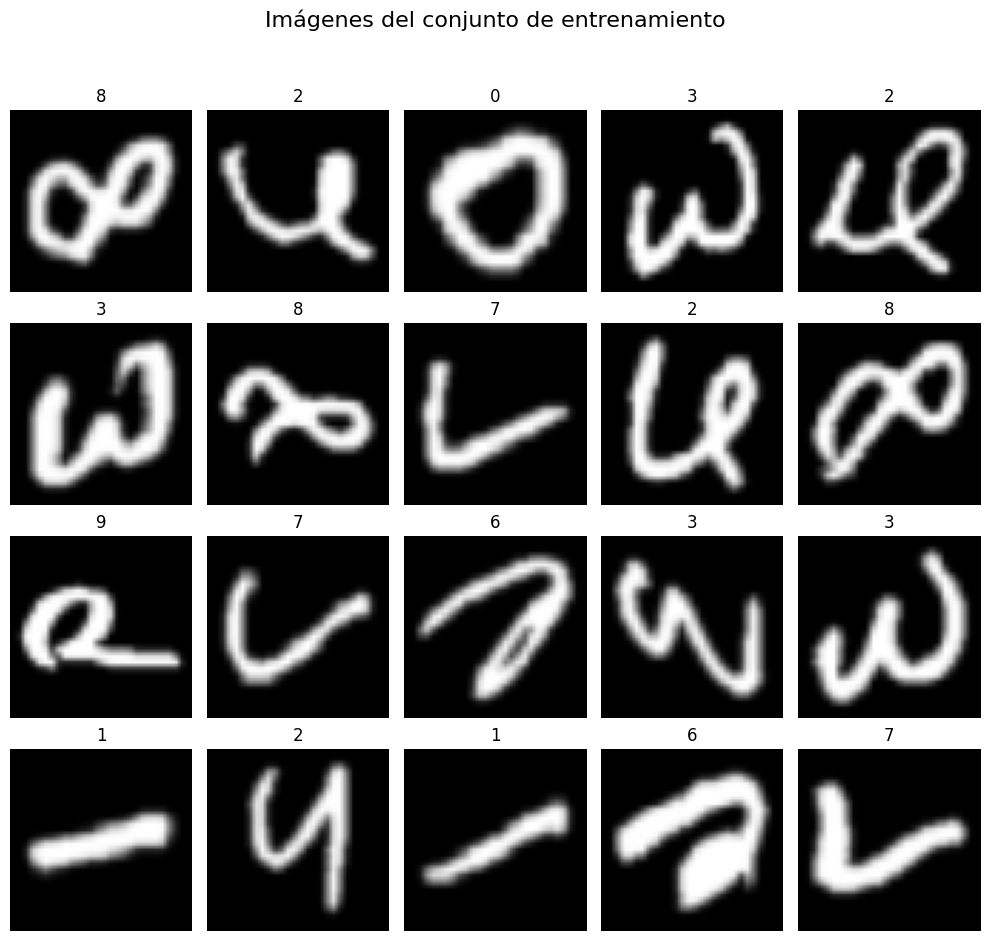

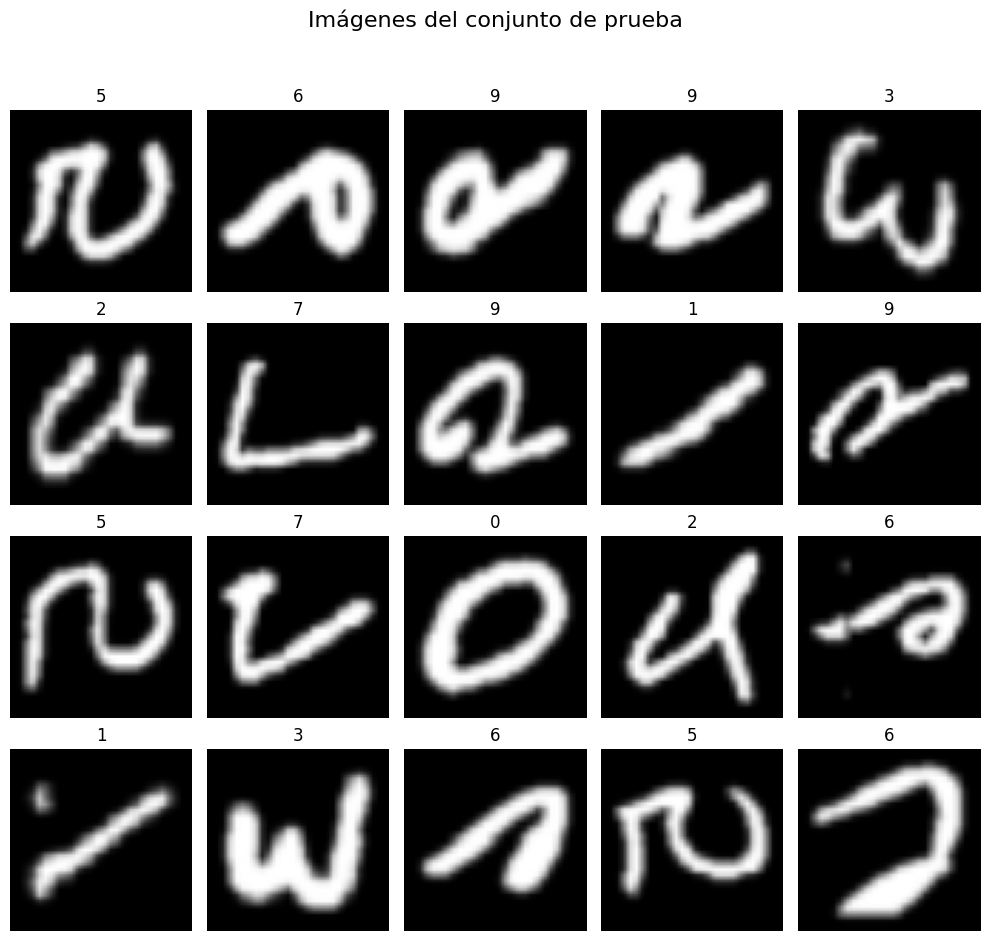

In [ ]:
mostrar_imagenes_aleatorias(x_entrenamiento_1, y_entrenamiento_1, mapping_1, cantidad=20, titulo="Imágenes del conjunto de entrenamiento")
mostrar_imagenes_aleatorias(x_prueba_1, y_prueba_1, mapping_1, cantidad=20, titulo="Imágenes del conjunto de prueba")

<h3>Creación de los modelos</h3>

In [51]:
shape_entrada_1 = (x_entrenamiento_1.shape[1], )
numero_clases_1 = len(np.unique(y_entrenamiento_1))

parametros_mlp1_exp1 = {'capas_ocultas': [256, 128], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}
parametros_mlp2_exp1 = {'capas_ocultas': [256, 128, 64], 'activacion': 'swish', 'loss': 'sparse_categorical_crossentropy'}
parametros_mlp3_exp1 = {'capas_ocultas': [512, 256, 128, 64], 'activacion': 'leaky_relu', 'loss': 'categorical_crossentropy'}

MLP1_exp1 = crear_modelo(
    capas_ocultas=parametros_mlp1_exp1['capas_ocultas'],
    activacion=parametros_mlp1_exp1['activacion'],
    loss=parametros_mlp1_exp1['loss'],
    optimizador=Nadam(learning_rate=0.0002),
    entradas=shape_entrada_1,
    salidas=numero_clases_1
)

MLP2_exp1 = crear_modelo(
    capas_ocultas=parametros_mlp2_exp1['capas_ocultas'],
    activacion=parametros_mlp2_exp1['activacion'],
    loss=parametros_mlp2_exp1['loss'],
    optimizador=AdamW(learning_rate=0.00015),
    entradas=shape_entrada_1,
    salidas=numero_clases_1
)

MLP3_exp1 = crear_modelo(
    capas_ocultas=parametros_mlp3_exp1['capas_ocultas'],
    activacion=parametros_mlp3_exp1['activacion'],
    loss=parametros_mlp3_exp1['loss'],
    optimizador=Adam(learning_rate=0.0002),
    entradas=shape_entrada_1,
    salidas=numero_clases_1
)

<h3>Entrenamiento y prueba del subconjunto EMNIST_Digits </h3>

In [52]:
resultados_1, tiempos_1 = entrenar_y_evaluar_modelos([MLP1_exp1, MLP2_exp1, MLP3_exp1], x_entrenamiento_1, y_entrenamiento_1, x_prueba_1, y_prueba_1, numero_clases_1)

Entrenando Modelo MLP1...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 865us/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step
Tiempo total para Modelo MLP1: 1670.10 segundos
Entrenando Modelo MLP2...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
Tiempo total para Modelo MLP2: 1859.39 segundos
Entrenando Modelo MLP3...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 4...
125

<h3>Resultados</h3>

Finalmente, se muestran los resultados obtenidos del entrenamiento y la evaluación de los modelos tales como el accuaracy, los gráficos y la matriz de confusión para cada MLP.

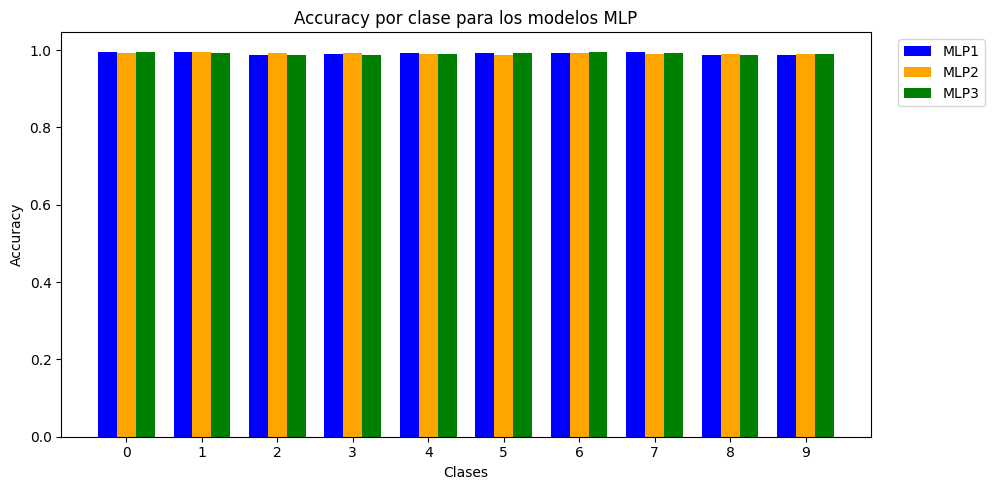

                   MLP1         MLP2         MLP3
Tiempo (s)  1670.097676  1859.389344  3104.886361

El tiempo total fue de: 6634.37 segundos

Modelo MLP1:
Mediana 5 iteraciones: 0.9909
Accuracy por clase: [0.99525 0.996   0.98625 0.99    0.9935  0.99125 0.99225 0.994   0.98725
 0.9875 ]
Accuracy total del modelo: 0.991325


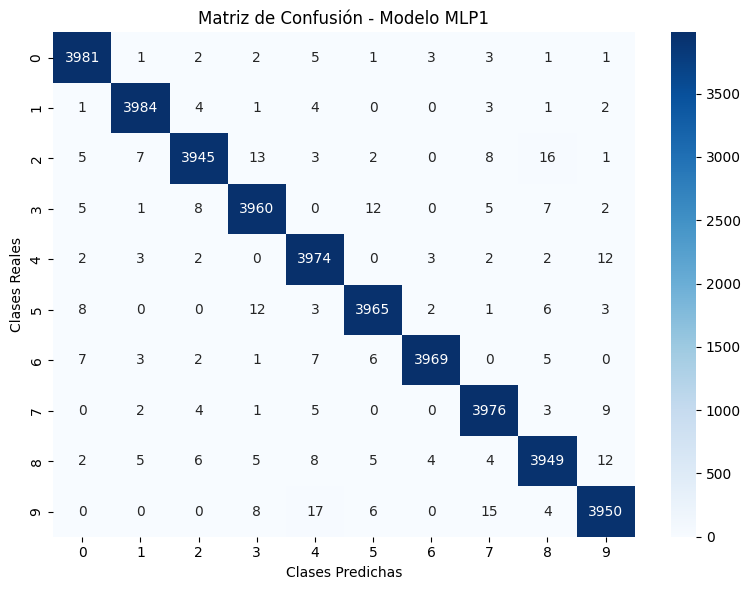


Modelo MLP2:
Mediana 5 iteraciones: 0.9908
Accuracy por clase: [0.9925  0.99525 0.99175 0.992   0.99    0.988   0.99325 0.98925 0.98975
 0.99   ]
Accuracy total del modelo: 0.991175


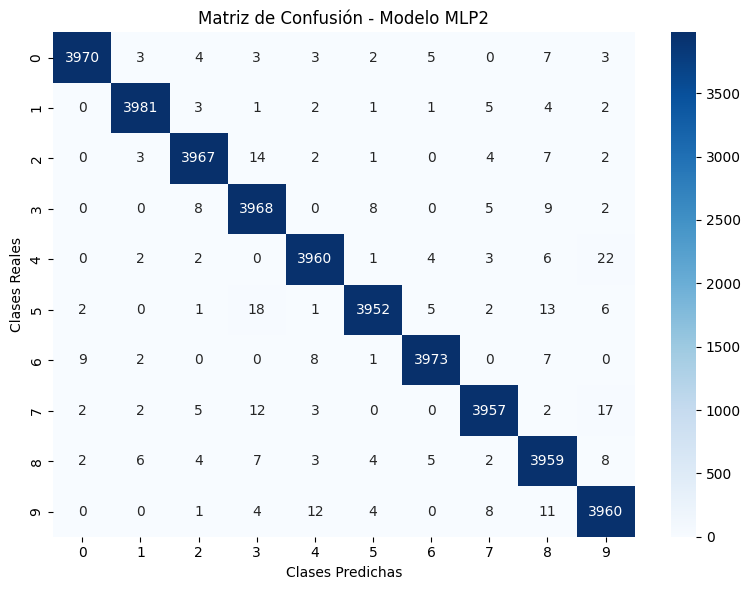


Modelo MLP3:
Mediana 5 iteraciones: 0.9901
Accuracy por clase: [0.9955  0.9935  0.98725 0.9865  0.9905  0.9915  0.9945  0.993   0.98725
 0.98975]
Accuracy total del modelo: 0.990925


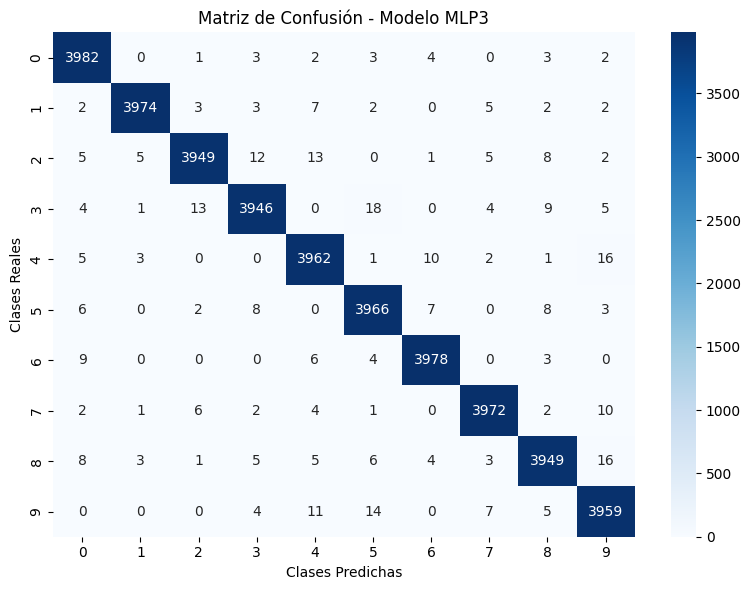


Mediana Diggits: 0.9908


In [53]:
colores = ['blue', 'orange', 'green']
etiquetas = ['MLP1', 'MLP2', 'MLP3']

# Crear gráfica de accuracy por clase
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25
x = np.arange(10)

for i, (_, acc_clase, _, _) in enumerate(resultados_1):
    bars = ax.bar(x + i * width, acc_clase, width=width, label=etiquetas[i], color=colores[i])

ax.set_xlabel("Clases")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por clase para los modelos MLP")
ax.set_xticks(x + width)
ax.set_xticklabels([str(i) for i in range(10)])
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

# Mostrar tiempos en tabla
tiempos_df = pd.DataFrame([tiempos_1], columns=etiquetas, index=["Tiempo (s)"])
print(tiempos_df)

# Imprimir tiempo total de ejecución
tiempo_total = sum(tiempos_1)
print(f"\nEl tiempo total fue de: {tiempo_total:.2f} segundos")

mediana_modelo = []
for i, (mediana_acc, acc_clase, matriz_conf, acc_totales) in enumerate(resultados_1):
    # Imprimir otras métricas
    print(f"\nModelo MLP{i + 1}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")
    print(f"Accuracy por clase: {acc_clase}")
    print(f"Accuracy total del modelo: {acc_totales}")
    mediana_modelo.append(mediana_acc)
    
    # Crear un heatmap para la matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        matriz_conf,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True
    )
    plt.title(f"Matriz de Confusión - Modelo MLP{i + 1}")
    plt.xlabel("Clases Predichas")
    plt.ylabel("Clases Reales")
    plt.tight_layout()
    plt.show()

print(f"\nMediana Diggits: {np.median(mediana_modelo):.4f}")

<h2>Experimento 2: Subconjunto EMNIST_Letters</h2>

El subconjunto EMNIST_Letters posee 26 clases las cuales representan las letras del abecedario inglés.

A continuación, se cargan los datos necesarios para el entrenamiento y prueba de los modelos

In [18]:
ruta_letters = "./emnist-letters"
# Concatena la ruta de los archivos con la carpeta de las letras con os
ruta_entrenamiento_imagenes = os.path.join(ruta_letters, "emnist-letters-train-images-idx3-ubyte.gz")
ruta_entrenamiento_etiquetas = os.path.join(ruta_letters, "emnist-letters-train-labels-idx1-ubyte.gz")
ruta_prueba_imagenes = os.path.join(ruta_letters, "emnist-letters-test-images-idx3-ubyte.gz")
ruta_prueba_etiquetas = os.path.join(ruta_letters, "emnist-letters-test-labels-idx1-ubyte.gz")
ruta_mapping = os.path.join(ruta_letters, "emnist-letters-mapping.txt")

x_entrenamiento, y_entrenamiento = cargar_datos(ruta_entrenamiento_imagenes, ruta_entrenamiento_etiquetas)
x_prueba, y_prueba = cargar_datos(ruta_prueba_imagenes, ruta_prueba_etiquetas)

x_entrenamiento = redimensionar_y_preprocesar(x_entrenamiento, (64, 64))
x_prueba = redimensionar_y_preprocesar(x_prueba, (64, 64))

mapping = cargar_mapping(ruta_mapping, "letters")

Luego, se muestran de forma aleatoria 20 imágenes tanto para el conjunto de entrenamiento como para el de prueba.

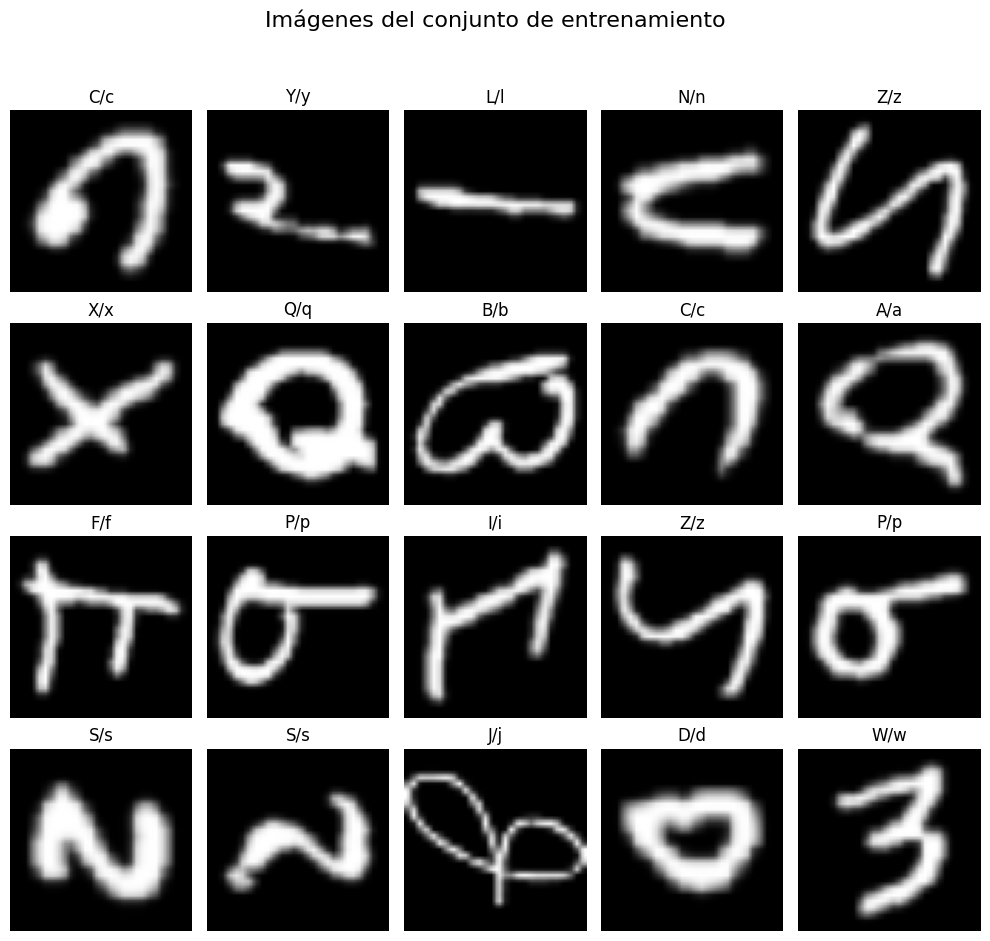

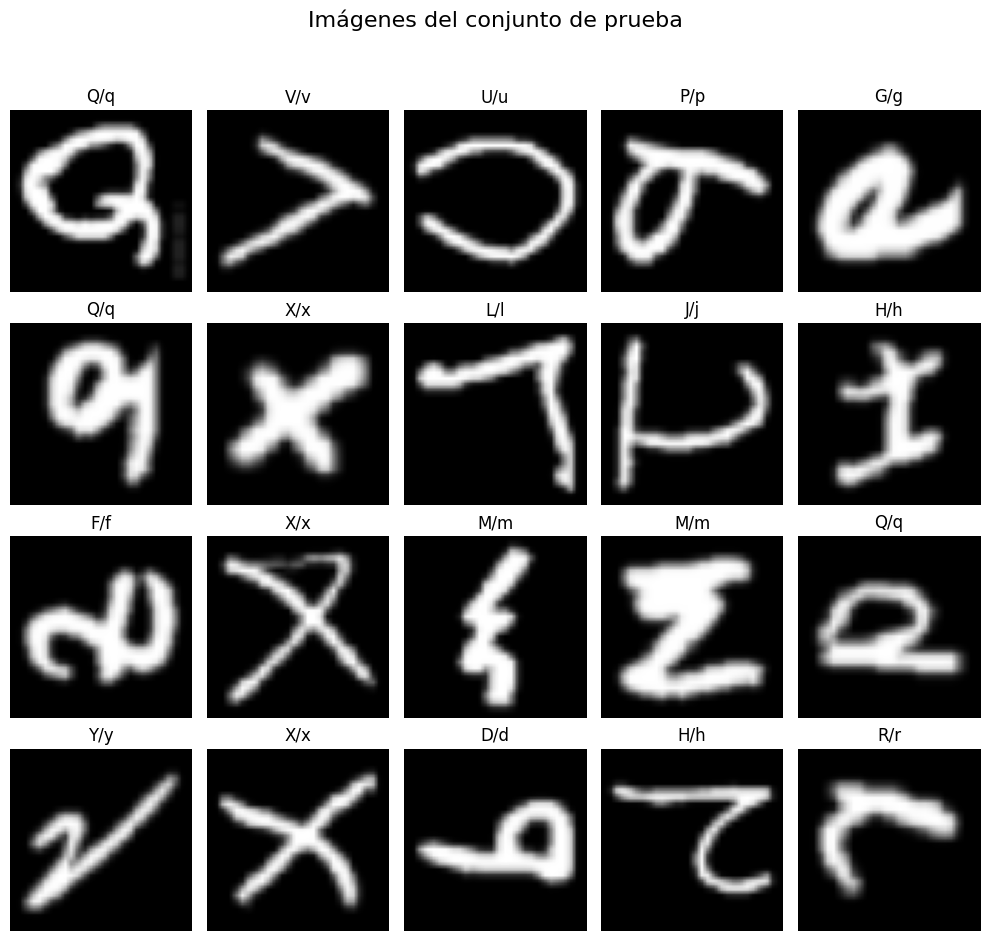

In [19]:
mostrar_imagenes_aleatorias(x_entrenamiento, y_entrenamiento, mapping, cantidad=20, titulo="Imágenes del conjunto de entrenamiento")
mostrar_imagenes_aleatorias(x_prueba, y_prueba, mapping, cantidad=20, titulo="Imágenes del conjunto de prueba")

<h3>Creación de los modelos</h3>

In [20]:
shape_entrada = (x_entrenamiento.shape[1], )
numero_clases = len(np.unique(y_entrenamiento))

## VER SI ES POR EL ESPACIO EN BLANCO DEL MAPPING<<<<<<<<<<<<<<<<<
y_entrenamiento = y_entrenamiento - 1
y_prueba = y_prueba - 1

parametros_mlp1_exp2 = {'capas_ocultas': [256, 128], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}
parametros_mlp2_exp2 = {'capas_ocultas': [256, 128, 64], 'activacion': 'swish', 'loss': 'sparse_categorical_crossentropy'}
parametros_mlp3_exp2 = {'capas_ocultas': [512, 256, 128, 64], 'activacion': 'leaky_relu', 'loss': 'categorical_crossentropy'}

MLP1_exp2 = crear_modelo(
    capas_ocultas=parametros_mlp1_exp2['capas_ocultas'],
    activacion=parametros_mlp1_exp2['activacion'],
    loss=parametros_mlp1_exp2['loss'],
    optimizador=Nadam(learning_rate=0.0002),
    entradas=shape_entrada,
    salidas=numero_clases
)

MLP2_exp2 = crear_modelo(
    capas_ocultas=parametros_mlp2_exp2['capas_ocultas'],
    activacion=parametros_mlp2_exp2['activacion'],
    loss=parametros_mlp2_exp2['loss'],
    optimizador=AdamW(learning_rate=0.00015),
    entradas=shape_entrada,
    salidas=numero_clases
)

MLP3_exp2 = crear_modelo(
    capas_ocultas=parametros_mlp3_exp2['capas_ocultas'],
    activacion=parametros_mlp3_exp2['activacion'],
    loss=parametros_mlp3_exp2['loss'],
    optimizador=Adam(learning_rate=0.0002),
    entradas=shape_entrada,
    salidas=numero_clases
)

<h3>Entrenamiento y prueba del subconjunto EMNIST_Letters </h3>

In [21]:
resultados, tiempos = entrenar_y_evaluar_modelos([MLP1_exp2, MLP2_exp2, MLP3_exp2], x_entrenamiento, y_entrenamiento, x_prueba, y_prueba, numero_clases)

Entrenando Modelo MLP1...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Tiempo total para Modelo MLP1: 1423.65 segundos
Entrenando Modelo MLP2...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Tiempo total para Modelo MLP2: 1064.05 segundos
Entrenando Modelo MLP3...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<h3>Resultados</h3>

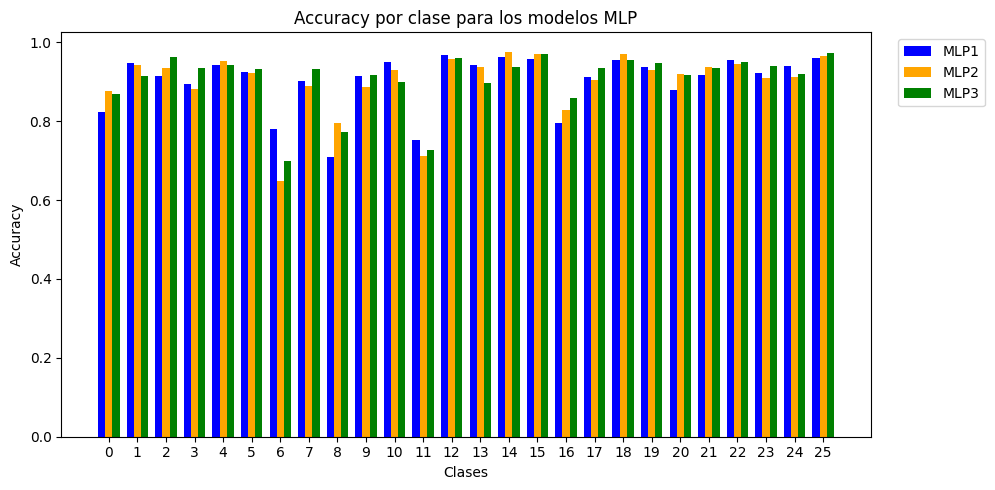

                   MLP1         MLP2         MLP3
Tiempo (s)  1423.652117  1064.052685  1995.123115

El tiempo total fue de: 4482.83 segundos

Modelo MLP1:
Mediana 5 iteraciones: 0.9019
Accuracy por clase: [0.82375 0.94625 0.915   0.895   0.9425  0.925   0.78125 0.90125 0.71
 0.91375 0.94875 0.7525  0.96875 0.9425  0.9625  0.9575  0.79625 0.9125
 0.95375 0.93625 0.88    0.9175  0.955   0.9225  0.93875 0.96125]
Accuracy total del modelo: 0.9023076923076923


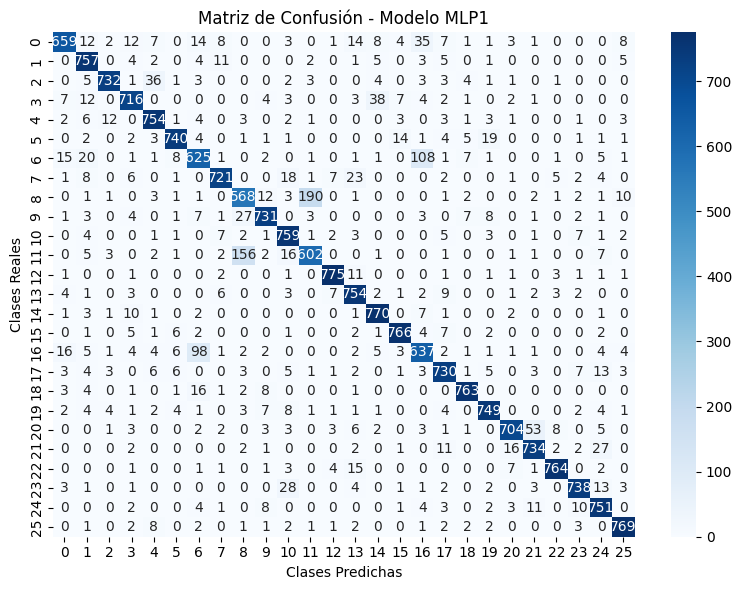


Modelo MLP2:
Mediana 5 iteraciones: 0.9028
Accuracy por clase: [0.8775  0.9425  0.93375 0.88125 0.95125 0.92125 0.64875 0.88875 0.795
 0.8875  0.93    0.71125 0.9575  0.93625 0.97625 0.97    0.8275  0.90375
 0.97125 0.92875 0.91875 0.9375  0.945   0.90875 0.9125  0.96625]
Accuracy total del modelo: 0.9011057692307692


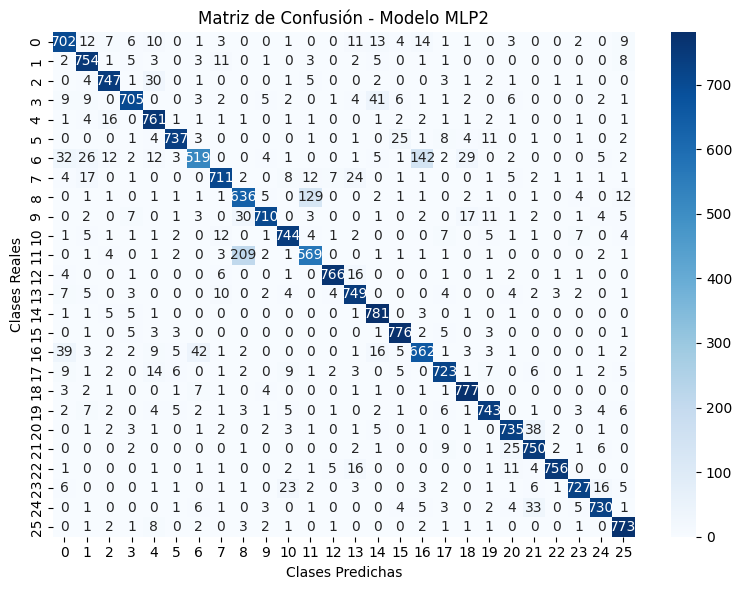


Modelo MLP3:
Mediana 5 iteraciones: 0.9015
Accuracy por clase: [0.87    0.91375 0.9625  0.935   0.94125 0.9325  0.7     0.93125 0.7725
 0.91625 0.9     0.72625 0.96    0.89625 0.93625 0.97125 0.8575  0.93375
 0.95375 0.9475  0.9175  0.93375 0.95    0.94    0.92    0.9725 ]
Accuracy total del modelo: 0.9073557692307692


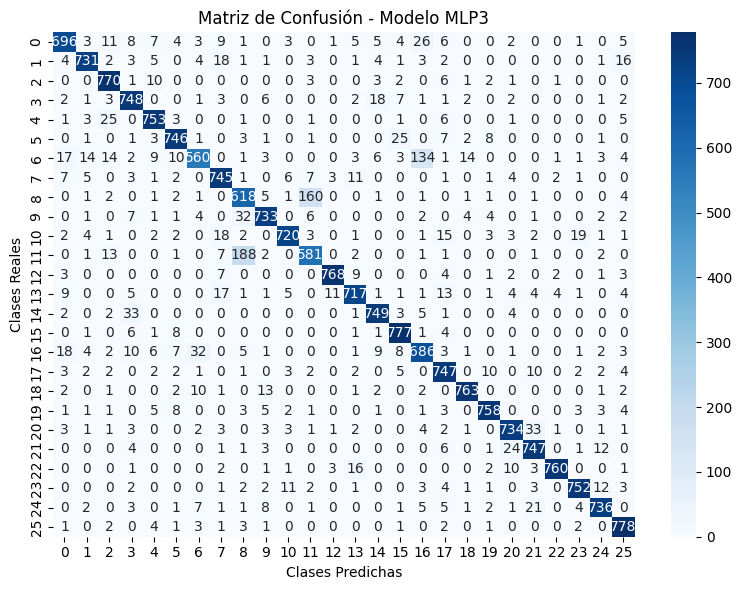


Mediana Letters: 0.9019


In [22]:
colores = ['blue', 'orange', 'green']
etiquetas = ['MLP1', 'MLP2', 'MLP3']

# Crear gráfica de accuracy por clase
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25
x = np.arange(26)

for i, (_, acc_clase, _, _) in enumerate(resultados):
    bars = ax.bar(x + i * width, acc_clase, width=width, label=etiquetas[i], color=colores[i])

ax.set_xlabel("Clases")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por clase para los modelos MLP")
ax.set_xticks(x + width)
ax.set_xticklabels([str(i) for i in range(26)])
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

# Mostrar tiempos en tabla
tiempos_df = pd.DataFrame([tiempos], columns=etiquetas, index=["Tiempo (s)"])
print(tiempos_df)

# Imprimir tiempo total de ejecución
tiempo_total = sum(tiempos)
print(f"\nEl tiempo total fue de: {tiempo_total:.2f} segundos")

mediana_modelo = []
for i, (mediana_acc, acc_clase, matriz_conf, acc_totales) in enumerate(resultados):
    # Imprimir otras métricas
    print(f"\nModelo MLP{i + 1}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")
    print(f"Accuracy por clase: {acc_clase}")
    print(f"Accuracy total del modelo: {acc_totales}")
    mediana_modelo.append(mediana_acc)
    
    # Crear un heatmap para la matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        matriz_conf,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True
    )
    plt.title(f"Matriz de Confusión - Modelo MLP{i + 1}")
    plt.xlabel("Clases Predichas")
    plt.ylabel("Clases Reales")
    plt.tight_layout()
    plt.show()

print(f"\nMediana Letters: {np.median(mediana_modelo):.4f}")

<h2>Referencias</h3>

- Jaiswal, S. (2024, 11 septiembre). Perceptrones multicapa en el aprendizaje automático: Guía completa. Datacamp. https://www.datacamp.com/es/tutorial/multilayer-perceptrons-in-machine-learning
- Gavilán, I. G. (2020, 27 mayo). Catálogo de componentes de redes neuronales (y IV): optimizadores. Ignacio G.R. Gavilán. https://ignaciogavilan.com/catalogo-de-componentes-de-redes-neuronales-y-iv-optimizadores/
- Papers with Code - AdamW Explained. (s. f.). https://paperswithcode.com/method/adamw